# MNIST Digit Classification using a Multi-Layer Perceptron (MLP)

This notebook builds, trains, evaluates, saves, and uses a 3-layer fully connected neural network on MNIST with PyTorch.

## 1. Environment Setup

Import dependencies and select an available device.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading and Preprocessing

`ToTensor` scales pixels to 0.0-1.0. MNIST is normalized with mean 0.1307 and standard deviation 0.3081. The requested training batch size is 10,000.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=10000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
print(f'Training samples: {len(train_dataset)}')
print(f'Testing samples: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]

Training samples: 60000
Testing samples: 10000


## 3. Data Visualization

Visualize sample images and the ten digit classes.

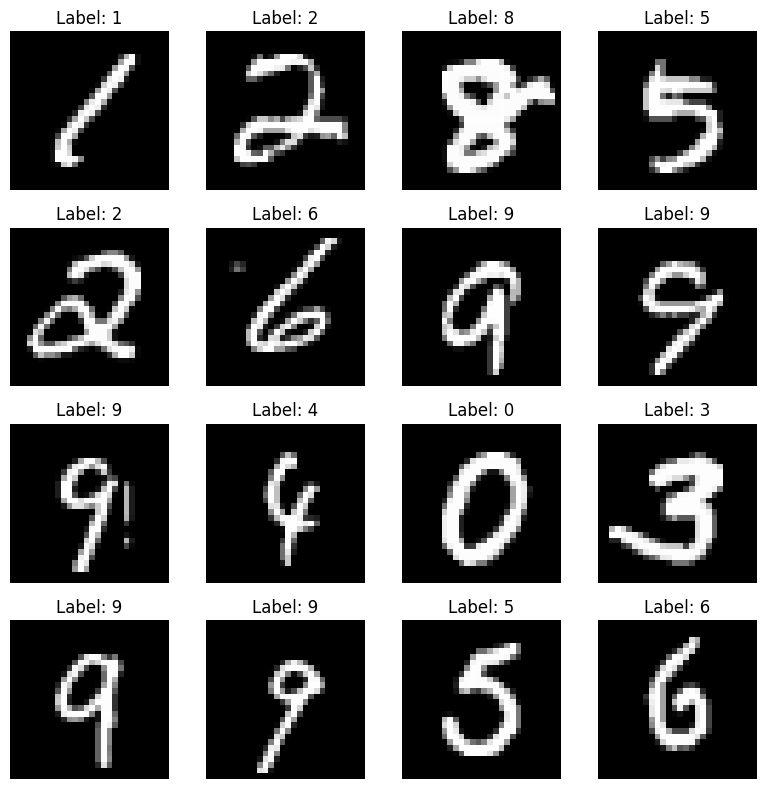

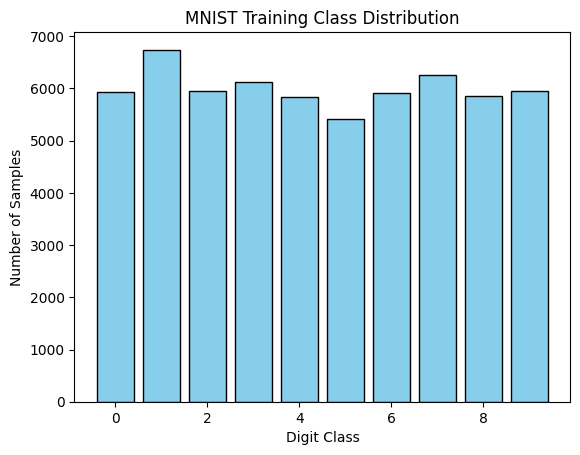

In [ ]:
def show_images(images, labels, count=16):
    images = (images * 0.3081 + 0.1307).numpy()
    figure, axes = plt.subplots(4, 4, figsize=(8, 8))
    for index, axis in enumerate(axes.flat):
        if index < count:
            axis.imshow(images[index].squeeze(), cmap='gray')
            axis.set_title(f'Label: {labels[index].item()}')
        axis.axis('off')
    plt.tight_layout()
    plt.show()

images, labels = next(iter(train_loader))
show_images(images[:16], labels[:16])
counts = torch.bincount(train_dataset.targets)
plt.bar(np.arange(10), counts.numpy(), color='skyblue', edgecolor='black')
plt.xlabel('Digit Class')
plt.ylabel('Number of Samples')
plt.title('MNIST Training Class Distribution')
plt.show()

## 4. Model Architecture

Digits 0 through 9 are ten classes. The corrected constructor is `__init__`, which is required for PyTorch module initialization.

In [ ]:
class ThreeLayerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = ThreeLayerMLP().to(device)
print(model)

ThreeLayerMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


## 5. Training

Train for seven epochs with Cross-Entropy Loss and Adam.

Epoch [1/7], Loss: 3.9164
Epoch [2/7], Loss: 1.1472
Epoch [3/7], Loss: 0.5250
Epoch [4/7], Loss: 0.3280
Epoch [5/7], Loss: 0.2298
Epoch [6/7], Loss: 0.1803
Epoch [7/7], Loss: 0.1482


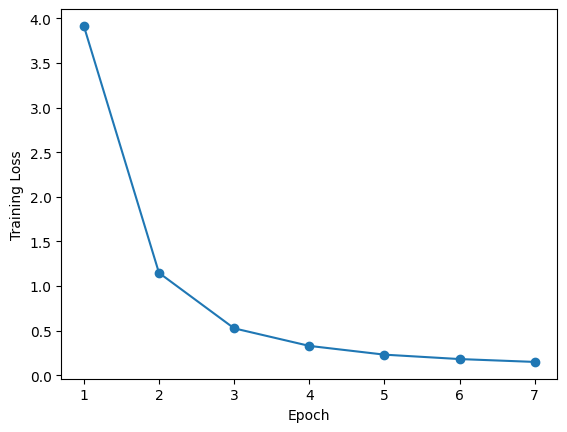

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 7
train_losses = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss:.4f}')
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()

## 6. Evaluation

Compute test accuracy and inspect predictions.

Test accuracy: 95.53%


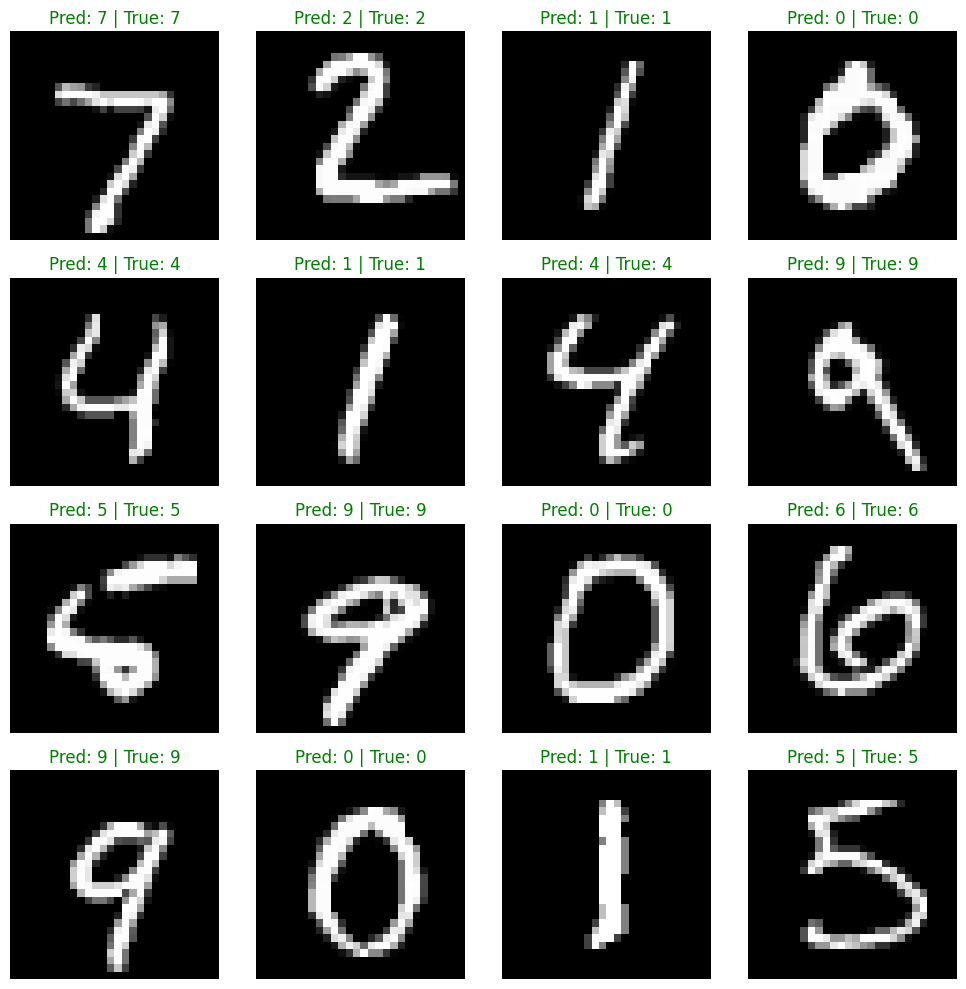

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for data, target in loader:
            predictions = model(data.to(device)).argmax(dim=1)
            correct += (predictions == target.to(device)).sum().item()
            total += target.size(0)
    return 100.0 * correct / total

accuracy = evaluate_model(model, test_loader)
print(f'Test accuracy: {accuracy:.2f}%')
images, labels = next(iter(test_loader))
with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()
figure, axes = plt.subplots(4, 4, figsize=(10, 10))
for index, axis in enumerate(axes.flat):
    axis.imshow((images[index] * 0.3081 + 0.1307).squeeze(), cmap='gray')
    color = 'green' if predictions[index] == labels[index] else 'red'
    axis.set_title(f'Pred: {predictions[index].item()} | True: {labels[index].item()}', color=color)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 7. Saving the Model

In [ ]:
model_save_path = 'mnist_mlp_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f'Model saved to {model_save_path}')

Model saved to mnist_mlp_model.pth


## 8. Inference Pipeline

Softmax gives proper probabilities for mutually exclusive digit classes. Sigmoid values are also returned for the originally requested activation output.

True label: 6
Predicted class: 6
Class 0: softmax=0.0001, sigmoid=0.8617
Class 1: softmax=0.0000, sigmoid=0.6313
Class 2: softmax=0.0002, sigmoid=0.9419
Class 3: softmax=0.0000, sigmoid=0.3603
Class 4: softmax=0.0012, sigmoid=0.9901
Class 5: softmax=0.0001, sigmoid=0.8996
Class 6: softmax=0.9983, sigmoid=1.0000
Class 7: softmax=0.0000, sigmoid=0.0075
Class 8: softmax=0.0000, sigmoid=0.5215
Class 9: softmax=0.0000, sigmoid=0.1736


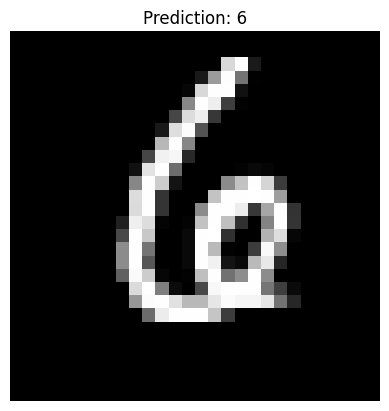

In [ ]:
def predict_single_image(image_tensor, model_path='mnist_mlp_model.pth'):
    inference_model = ThreeLayerMLP().to(device)
    inference_model.load_state_dict(torch.load(model_path, map_location=device))
    inference_model.eval()
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    with torch.no_grad():
        logits = inference_model(image_tensor.to(device))
        predicted_class = logits.argmax(dim=1)
        softmax_probs = torch.softmax(logits, dim=1)
        sigmoid_values = torch.sigmoid(logits)
    return predicted_class.item(), softmax_probs.squeeze(0).cpu().numpy(), sigmoid_values.squeeze(0).cpu().numpy()

sample_image, sample_label = test_dataset[123]
predicted, probabilities, sigmoid_values = predict_single_image(sample_image)
print(f'True label: {sample_label}')
print(f'Predicted class: {predicted}')
for index, probability in enumerate(probabilities):
    print(f'Class {index}: softmax={probability:.4f}, sigmoid={sigmoid_values[index]:.4f}')
plt.imshow(sample_image.squeeze().numpy() * 0.3081 + 0.1307, cmap='gray')
plt.title(f'Prediction: {predicted}')
plt.axis('off')
plt.show()

##9. Testing with an online found Image of 8

Class 0: softmax=0.0207, sigmoid=0.4298
Class 1: softmax=0.0376, sigmoid=0.5780
Class 2: softmax=0.0295, sigmoid=0.5180
Class 3: softmax=0.1967, sigmoid=0.8776
Class 4: softmax=0.0283, sigmoid=0.5079
Class 5: softmax=0.1675, sigmoid=0.8593
Class 6: softmax=0.0355, sigmoid=0.5644
Class 7: softmax=0.0247, sigmoid=0.4737
Class 8: softmax=0.3848, sigmoid=0.9335
Class 9: softmax=0.0747, sigmoid=0.7316


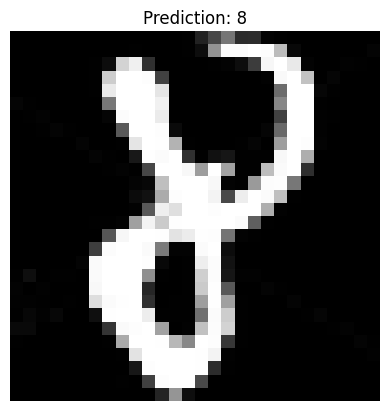

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

img = cv2.imread('/content/num8.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))
img = cv2.bitwise_not(img)
cv2_imshow(img)
img = img.astype(np.float32) / 255.0
img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
predicted, probabilities, sigmoid_values = predict_single_image(img_tensor)
for index, probability in enumerate(probabilities):
    print(f'Class {index}: softmax={probability:.4f}, sigmoid={sigmoid_values[index]:.4f}')
plt.imshow(img_tensor.squeeze().numpy() * 0.3081 + 0.1307, cmap='gray')
plt.title(f'Prediction: {predicted}')
plt.axis('off')
plt.show()

##9. Testing with an online found Image of 5

Class 0: softmax=0.0000, sigmoid=0.9144
Class 1: softmax=0.0000, sigmoid=0.0003
Class 2: softmax=0.0000, sigmoid=0.0016
Class 3: softmax=0.0000, sigmoid=0.9976
Class 4: softmax=0.0000, sigmoid=0.0878
Class 5: softmax=0.5257, sigmoid=1.0000
Class 6: softmax=0.0000, sigmoid=0.9931
Class 7: softmax=0.0000, sigmoid=0.9942
Class 8: softmax=0.0002, sigmoid=0.9998
Class 9: softmax=0.4741, sigmoid=1.0000


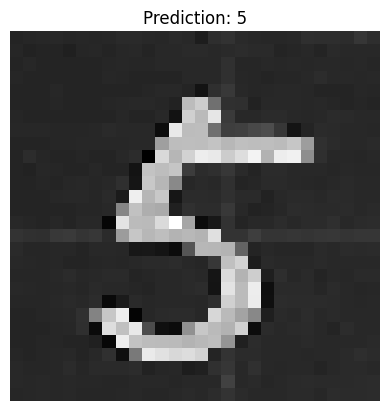

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

img = cv2.imread('/content/num5.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))
img = cv2.bitwise_not(img)
cv2_imshow(img)
img = img.astype(np.float32) / 255.0
img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
predicted, probabilities, sigmoid_values = predict_single_image(img_tensor)
for index, probability in enumerate(probabilities):
    print(f'Class {index}: softmax={probability:.4f}, sigmoid={sigmoid_values[index]:.4f}')
plt.imshow(img_tensor.squeeze().numpy() * 0.3081 + 0.1307, cmap='gray')
plt.title(f'Prediction: {predicted}')
plt.axis('off')
plt.show()